# NAS-Bench-301 — DARTS Search Space

Analisi dello spazio di ricerca DARTS tramite NAS-Bench-301 (surrogate model).

## Differenze rispetto a NATS-Bench TSS

| | NATS-Bench TSS | NAS-Bench-301 / DARTS |
|---|---|---|
| Architetture | 15.625 | ~10¹⁸ (campionate) |
| Struttura | 1 cella, 4 nodi | 2 celle (normal + reduce), 4 nodi ciascuna |
| Operazioni | 6 | 8 |
| Encoding | (6, 4, 4) = 96 dim | (2, 8, 6, 6) = 576 dim |
| Accuratezza | Lookup table reale | Surrogate model (GNN ensemble) |

### Struttura della cella DARTS
Ogni cella ha 2 nodi input fissi (`inp0`, `inp1`) e 4 nodi intermedi (`n0`–`n3`).  
Ogni nodo intermedio riceve **esattamente 2 archi** da nodi precedenti, ognuno con un'operazione.

In [1]:
!pip install nasbench301
!pip install tensorflow


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip uninstall ConfigSpace -y
!pip install --no-binary :all: ConfigSpace==0.4.21

Found existing installation: ConfigSpace 0.6.1
Uninstalling ConfigSpace-0.6.1:
  Successfully uninstalled ConfigSpace-0.6.1


You can safely remove it manually.


  Using cached configspace-0.4.21-cp311-cp311-win_amd64.whl



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!py -3.9 -m venv nb301_env
!nb301_env\Scripts\activate
!pip install nasbench301

"py" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.
Impossibile trovare il percorso specificato.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
!pip install xgboost==1.5.0  


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# Discard the old version entirely
!pip uninstall ConfigSpace -y
# Install the patched 0.6.1 version
!pip install ConfigSpace==0.6.1
# Keep your numpy cap, as numpy 2.0+ will break TensorFlow and NAS-Bench
!pip install "numpy<2"

Found existing installation: ConfigSpace 0.4.21
Uninstalling ConfigSpace-0.4.21:
  Successfully uninstalled ConfigSpace-0.4.21
  Using cached ConfigSpace-0.6.1-cp311-cp311-win_amd64.whl.metadata (3.3 kB)
Using cached ConfigSpace-0.6.1-cp311-cp311-win_amd64.whl (746 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Setup

### Download modelli surrogati (prima esecuzione)
I modelli NAS-Bench-301 devono essere scaricati (~2 GB) la prima volta.  
Puoi farlo con:

```python
import nasbench301 as nb
nb.download_models(save_dir=NB301_DIR)
```

Oppure manualmente da: https://figshare.com/articles/software/nasbench301_models_v1_0/13061510

In [7]:
import ConfigSpace
import numpy as np
import nasbench301 as nb
print(ConfigSpace.__version__)  # deve essere 0.4.x
print(np.__version__)

tensorflow is not installed.
0.6.1
1.26.4


In [8]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import namedtuple

# ── PATH CONFIG ──────────────────────────────────────────────────────────
# Questo notebook sta in progetto-deeplearning/latent_space/
# I dataset stanno in progetto-deeplearning/datasets/
BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
DATASETS_DIR = os.path.abspath(os.path.join(BASE_DIR, '../datasets'))
NB301_DIR    = os.path.join(DATASETS_DIR, 'nb301_models')

# ── SEED ──────────────────────────────────────────────────────────────────
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## Caricamento API NAS-Bench-301

In [ ]:
import nasbench301 as nb

# Download modelli (solo la prima volta — commenta dopo il primo run)
model_dir = os.path.join("nb_models_1.0", "xgb_v1.0")

# Se i modelli non esistono nella cartella, li scarichiamo (circa 100-200MB)
if not os.path.exists(model_dir):
    print("Scaricamento dei pesi dei modelli in corso (potrebbe volerci un minuto)...")
    nb.download_models(version="1.0")
else:
    print("Pesi dei modelli trovati localmente!")

# Carica il surrogate ensemble (versione 0.9 — più accurata)
ensemble_dir_perf = os.path.join('nb_models_1.0', 'xgb_v1.0')
performance_model = nb.load_ensemble(ensemble_dir_perf)

print('Surrogate model caricato con successo!')

Surrogate model caricato con successo!


## API Inspection — struttura di un'architettura DARTS

Un `Genotype` DARTS è composto da:
- `normal`: lista di 8 coppie `(op_name, src_node)`, 2 per ogni nodo intermedio
- `normal_concat`: nodi che confluiscono nell'output della cella (solitamente `[2, 3, 4, 5]`)
- `reduce`: stessa struttura per la cella di riduzione
- `reduce_concat`: idem

Le 8 operazioni disponibili sono le stesse del paper DARTS originale.

In [10]:
# Operazioni disponibili — stesso set del paper DARTS
PRIMITIVES = [
    'max_pool_3x3',
    'avg_pool_3x3',
    'skip_connect',
    'sep_conv_3x3',
    'sep_conv_5x5',
    'dil_conv_3x3',
    'dil_conv_5x5',
]

N_OPS        = len(PRIMITIVES)   # 8
N_NODES      = 4                 # nodi intermedi per cella
N_INPUTS     = 2                 # ingressi fissi (inp0, inp1)
TOTAL_NODES  = N_INPUTS + N_NODES  # 6 nodi totali per cella

# Tipo Genotype (compatibile con il formato nasbench301)
Genotype = namedtuple('Genotype', 'normal normal_concat reduce reduce_concat')

def random_cell():
    """
    Genera una cella DARTS casuale.
    Ogni nodo intermedio i riceve 2 archi da nodi in {0, ..., N_INPUTS + i - 1}.
    Ritorna lista di 8 coppie (op_name, src_node).
    """
    edges = []
    for node_idx in range(N_NODES):
        n_available = N_INPUTS + node_idx  # quanti predecessori esistono
        srcs = random.sample(range(n_available), 2)
        for src in sorted(srcs):
            op = random.choice(PRIMITIVES)
            edges.append((op, src))
    return edges

def random_genotype():
    return Genotype(
        normal         = random_cell(),
        normal_concat  = list(range(N_INPUTS, TOTAL_NODES)),  # [2, 3, 4, 5]
        reduce         = random_cell(),
        reduce_concat  = list(range(N_INPUTS, TOTAL_NODES)),
    )

# Esempio di architettura
example_geno = random_genotype()
print('Esempio architettura DARTS:')
print(example_geno)
print()
predicted_acc = performance_model.predict(
    config=example_geno,
    representation='genotype',
    with_noise=False
)
print(f'Accuratezza predetta dal surrogate: {predicted_acc:.2f}%')

Esempio architettura DARTS:
Genotype(normal=[('dil_conv_3x3', 0), ('skip_connect', 1), ('avg_pool_3x3', 0), ('dil_conv_3x3', 2), ('dil_conv_3x3', 0), ('sep_conv_5x5', 2), ('max_pool_3x3', 0), ('max_pool_3x3', 3)], normal_concat=[2, 3, 4, 5], reduce=[('avg_pool_3x3', 0), ('sep_conv_5x5', 1), ('sep_conv_5x5', 0), ('avg_pool_3x3', 2), ('sep_conv_3x3', 0), ('sep_conv_5x5', 3), ('dil_conv_5x5', 0), ('dil_conv_5x5', 2)], reduce_concat=[2, 3, 4, 5])

Accuratezza predetta dal surrogate: 93.34%


## Encoding — Genotype → Tensore di adiacenza

Analogamente a NATS-Bench (che usava shape `(6, 4, 4) = 96 dim`), rappresentiamo ogni cella DARTS come un tensore di adiacenza:

$$A^{\text{cella}}[\text{op}, \text{src}, \text{dst}] \in \{0, 1\}$$

con shape `(8, 6, 6)` dove:
- dim 0: operazione (8 PRIMITIVES)
- dim 1: nodo sorgente (`inp0=0, inp1=1, n0=2, n1=3, n2=4, n3=5`)
- dim 2: nodo destinazione (solo i nodi intermedi `2..5` ricevono archi)

Per le 2 celle (normal + reduce): `2 × 8 × 6 × 6 = 576` valori totali.

In [11]:
OP_TO_IDX = {op: i for i, op in enumerate(PRIMITIVES)}

def cell_to_tensor(cell_edges):
    """
    Converte una lista DARTS di (op, src) in A[op, src, dst].
    
    Shape: (N_OPS=8, TOTAL_NODES=6, TOTAL_NODES=6)
    Ogni nodo intermedio dst riceve esattamente 2 archi.
    Flattened: 8 * 6 * 6 = 288 valori.
    """
    A = np.zeros((N_OPS, TOTAL_NODES, TOTAL_NODES), dtype=np.float32)
    edge_idx = 0
    for dst_offset in range(N_NODES):       # nodi intermedi: n0, n1, n2, n3
        dst = N_INPUTS + dst_offset         # indici: 2, 3, 4, 5
        for _ in range(2):                  # 2 archi entranti per nodo
            op_name, src = cell_edges[edge_idx]
            A[OP_TO_IDX[op_name], src, dst] = 1.0
            edge_idx += 1
    return A

def genotype_to_tensor(genotype):
    """
    Converte un Genotype DARTS in un vettore piatto.
    Stack di normal + reduce cell → shape finale: (576,)
    """
    normal_A = cell_to_tensor(genotype.normal)   # (8, 6, 6)
    reduce_A = cell_to_tensor(genotype.reduce)   # (8, 6, 6)
    both     = np.stack([normal_A, reduce_A])    # (2, 8, 6, 6)
    return both.flatten()                        # (576,)

# Verifica
t = genotype_to_tensor(example_geno)
print(f'Tensor shape: {t.shape}')                     # (576,)
print(f'Valori non-zero: {(t > 0).sum()}')            # 2 archi × 4 nodi × 2 celle = 16
print(f'\nConfronro con NATS-Bench TSS:')
print(f'  NATS-Bench TSS : (6, 4, 4) = 96  dim')
print(f'  DARTS NB301    : (2, 8, 6, 6) = 576 dim  ({576//96}x più grande)')

Tensor shape: (504,)
Valori non-zero: 16

Confronro con NATS-Bench TSS:
  NATS-Bench TSS : (6, 4, 4) = 96  dim
  DARTS NB301    : (2, 8, 6, 6) = 576 dim  (6x più grande)


## Costruzione Dataset

Campioniamo `N_ARCHS` architetture casuali e usiamo il surrogate per predire le accuratezze su CIFAR-10.

In [29]:
N_ARCHS = 15000

print(f'Campionamento di {N_ARCHS} architetture DARTS...')
genotypes   = [random_genotype() for _ in range(N_ARCHS)]
all_tensors = [genotype_to_tensor(g) for g in genotypes]
X = np.stack(all_tensors)   # (N_ARCHS, 576)

print('Predizione accuratezze con il surrogate NAS-Bench-301...')
accuracies = []
for i, g in enumerate(genotypes):
    acc = performance_model.predict(
        config=g,
        representation='genotype',
        with_noise=False
    )
    accuracies.append(acc)
    if i % 2000 == 0:
        print(f'  [{i:>5}/{N_ARCHS}]  acc media finora: {np.mean(accuracies):.2f}%')

y_np = np.array(accuracies, dtype=np.float32)

print(f'\nX shape  : {X.shape}')
print(f'y shape  : {y_np.shape}')
print(f'Accuracy — min: {y_np.min():.2f}%  max: {y_np.max():.2f}%  media: {y_np.mean():.2f}%')

Campionamento di 15000 architetture DARTS...
Predizione accuratezze con il surrogate NAS-Bench-301...
  [    0/15000]  acc media finora: 93.94%
  [ 2000/15000]  acc media finora: 93.08%
  [ 4000/15000]  acc media finora: 93.09%
  [ 6000/15000]  acc media finora: 93.10%
  [ 8000/15000]  acc media finora: 93.10%
  [10000/15000]  acc media finora: 93.09%
  [12000/15000]  acc media finora: 93.09%
  [14000/15000]  acc media finora: 93.09%

X shape  : (15000, 504)
y shape  : (15000,)
Accuracy — min: 89.62%  max: 94.61%  media: 93.09%


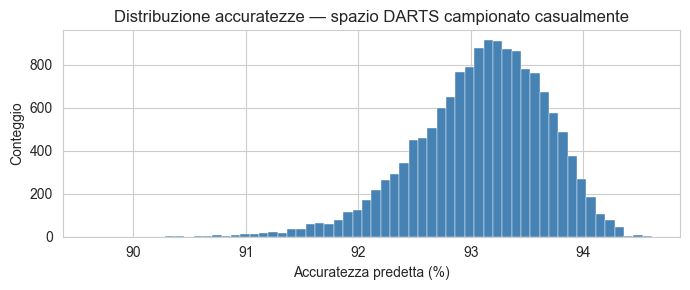

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
plt.hist(y_np, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
plt.xlabel('Accuratezza predetta (%)')
plt.ylabel('Conteggio')
plt.title('Distribuzione accuratezze — spazio DARTS campionato casualmente')
plt.tight_layout()
plt.show()

## DataLoader

In [31]:
from torch.utils.data import TensorDataset, DataLoader, random_split

X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y_np / 100.0, dtype=torch.float32)  # normalizza in [0, 1]

dataset    = TensorDataset(X_torch, y_torch)
train_size = int(0.8 * len(dataset))
test_size  = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f'Train: {train_size} | Test: {test_size}')

Train: 12000 | Test: 3000


## VAE — adattato per lo spazio DARTS (576 dim)

Rispetto al VAE per NATS-Bench (96→16 dim), questo è più profondo per gestire l'input 6× più grande.

| | NATS-Bench VAE | DARTS VAE |
|---|---|---|
| Input dim | 96 | 576 |
| Latent dim | 16 | 32 |
| Encoder | 96→128→64→(μ,σ) | 576→512→256→128→(μ,σ) |

In [32]:
LATENT_DIM = 32
INPUT_DIM  = 504   # 2 * 8 * 6 * 6


class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        # --------------------
        # Encoder
        # --------------------
        self.enc1 = nn.Linear(INPUT_DIM, 512)
        self.enc2 = nn.Linear(512, 256)
        self.enc3 = nn.Linear(256, 128)
        self.mu     = nn.Linear(128, LATENT_DIM)
        self.logvar = nn.Linear(128, LATENT_DIM)

        # --------------------
        # Decoder
        # --------------------
        self.dec1 = nn.Linear(LATENT_DIM, 128)
        self.dec2 = nn.Linear(128, 256)
        self.dec3 = nn.Linear(256, 512)
        self.dec4 = nn.Linear(512, INPUT_DIM)

        # --------------------
        # Predictor (accuracy head)
        # --------------------
        self.acc_predictor = nn.Sequential(
            nn.Linear(LATENT_DIM, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def encode(self, x):
        h = F.relu(self.enc1(x))
        h = F.relu(self.enc2(h))
        h = F.relu(self.enc3(h))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.dec1(z))
        h = F.relu(self.dec2(h))
        h = F.relu(self.dec3(h))
        return torch.sigmoid(self.dec4(h))

    def predict_acc(self, z):
        return self.acc_predictor(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        recon      = self.decode(z)
        acc_pred   = self.predict_acc(z)
        return recon, mu, logvar, acc_pred

## Loss Functions

- **`vae_loss`**: reconstruction (BCE) + KL divergence
- **`vae_accuracy_loss`**: reconstruction (MSE) + KL + differenza accuratezza predetta vs reale

In [33]:
def vae_loss(recon, x, mu, logvar, beta=1):

    recon_loss = F.binary_cross_entropy(
        recon, x, reduction='sum'
    )

    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl * beta


def vae_accuracy_loss(
    recon, x, mu, logvar,
    pred_acc, true_acc,
    beta=1.0, lambda_acc=1.0
):

    recon_loss = F.mse_loss(recon, x)

    kl = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    acc_loss = F.mse_loss(pred_acc.squeeze(), true_acc)

    loss = recon_loss + beta * kl + lambda_acc * acc_loss

    return loss, recon_loss, kl, acc_loss

## Training — VAE + Accuracy Loss

In [34]:
epochs     = 50
lambda_acc = 1.0
beta       = 1.2

model_acc = VAE().to(DEVICE)
optimizer = torch.optim.Adam(model_acc.parameters(), lr=1e-3)

model_acc.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        x = batch[0].to(DEVICE)
        y = batch[1].to(DEVICE)

        recon, mu, logvar, pred_acc = model_acc(x)

        loss, _, _, _ = vae_accuracy_loss(
            recon, x, mu, logvar, pred_acc, y,
            beta=beta, lambda_acc=lambda_acc
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f'Epoch {epoch+1:>2} | Loss: {total_loss:.4f}')

Epoch  1 | Loss: 11.8394
Epoch  2 | Loss: 3.8410
Epoch  3 | Loss: 3.5855
Epoch  4 | Loss: 3.4058
Epoch  5 | Loss: 3.2594
Epoch  6 | Loss: 3.1560
Epoch  7 | Loss: 3.0912
Epoch  8 | Loss: 3.0488
Epoch  9 | Loss: 3.0214
Epoch 10 | Loss: 3.0057
Epoch 11 | Loss: 2.9964
Epoch 12 | Loss: 2.9888
Epoch 13 | Loss: 2.9860
Epoch 14 | Loss: 2.9709
Epoch 15 | Loss: 2.9227
Epoch 16 | Loss: 2.7599
Epoch 17 | Loss: 2.7298
Epoch 18 | Loss: 2.7242
Epoch 19 | Loss: 2.7216
Epoch 20 | Loss: 2.7206
Epoch 21 | Loss: 2.7192
Epoch 22 | Loss: 2.7187
Epoch 23 | Loss: 2.7184
Epoch 24 | Loss: 2.7183
Epoch 25 | Loss: 2.7177
Epoch 26 | Loss: 2.7177
Epoch 27 | Loss: 2.7178
Epoch 28 | Loss: 2.7174
Epoch 29 | Loss: 2.7174
Epoch 30 | Loss: 2.7172
Epoch 31 | Loss: 2.7170
Epoch 32 | Loss: 2.7174
Epoch 33 | Loss: 2.7169
Epoch 34 | Loss: 2.7171
Epoch 35 | Loss: 2.7172
Epoch 36 | Loss: 2.7168
Epoch 37 | Loss: 2.7171
Epoch 38 | Loss: 2.7165
Epoch 39 | Loss: 2.7171
Epoch 40 | Loss: 2.7167
Epoch 41 | Loss: 2.7170
Epoch 42 | Loss

In [35]:
from sklearn.decomposition import PCA

model_acc.eval()

X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
y_train = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))])

with torch.no_grad():
    mu_acc, logvar_acc = model_acc.encode(X_train.to(DEVICE))

z_acc    = mu_acc.cpu().numpy()
pca_acc  = PCA(n_components=2)
z_2d_acc = pca_acc.fit_transform(z_acc)

print(f'Latent shape: {z_acc.shape}')   # (8000, 32)
print(f'PCA explained variance: {pca_acc.explained_variance_ratio_.sum():.3f}')

Latent shape: (12000, 32)
PCA explained variance: 0.244


## Training — VAE base (solo ricostruzione + KL)

In [36]:
epochs = 50
beta   = 1.3

model_base = VAE().to(DEVICE)
optimizer  = torch.optim.Adam(model_base.parameters(), lr=1e-3)

model_base.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        x = batch[0].to(DEVICE)
        y = batch[1].to(DEVICE)

        recon, mu, logvar, _ = model_base(x)

        loss = vae_loss(recon, x, mu, logvar, beta=beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f'Epoch {epoch+1:>2} | Loss: {total_loss:.4f}')

Epoch  1 | Loss: 964847.3828
Epoch  2 | Loss: 664236.1294
Epoch  3 | Loss: 663048.3330
Epoch  4 | Loss: 661314.8398
Epoch  5 | Loss: 660362.2808
Epoch  6 | Loss: 658935.9839
Epoch  7 | Loss: 657990.2949
Epoch  8 | Loss: 657168.7466
Epoch  9 | Loss: 656294.5244
Epoch 10 | Loss: 655676.6978
Epoch 11 | Loss: 655463.4023
Epoch 12 | Loss: 655239.5132
Epoch 13 | Loss: 655036.8662
Epoch 14 | Loss: 654913.4565
Epoch 15 | Loss: 654803.2876
Epoch 16 | Loss: 654762.9956
Epoch 17 | Loss: 654626.9717
Epoch 18 | Loss: 654474.5938
Epoch 19 | Loss: 654426.1650
Epoch 20 | Loss: 654380.3955
Epoch 21 | Loss: 654299.9390
Epoch 22 | Loss: 654329.1431
Epoch 23 | Loss: 654381.6470
Epoch 24 | Loss: 654235.2705
Epoch 25 | Loss: 654174.7441
Epoch 26 | Loss: 654052.7905
Epoch 27 | Loss: 654122.9194
Epoch 28 | Loss: 654119.2021
Epoch 29 | Loss: 654091.7451
Epoch 30 | Loss: 654040.7915
Epoch 31 | Loss: 654019.3613
Epoch 32 | Loss: 653990.3232
Epoch 33 | Loss: 654016.3921
Epoch 34 | Loss: 654001.6191
Epoch 35 | Los

In [37]:
model_base.eval()

with torch.no_grad():
    mu_base, _ = model_base.encode(X_train.to(DEVICE))

z_base    = mu_base.cpu().numpy()
pca_base  = PCA(n_components=2)
z_2d_base = pca_base.fit_transform(z_base)

print(f'PCA explained variance (base): {pca_base.explained_variance_ratio_.sum():.3f}')

PCA explained variance (base): 0.412


## Visualizzazione — confronto spazi latenti

Analogamente al notebook NATS-Bench, confrontiamo:
- **VAE + Accuracy loss**: il supervisore spinge architetture simili in termini di accuracy vicine nello spazio latente
- **VAE base**: organizzazione guidata solo dalla struttura

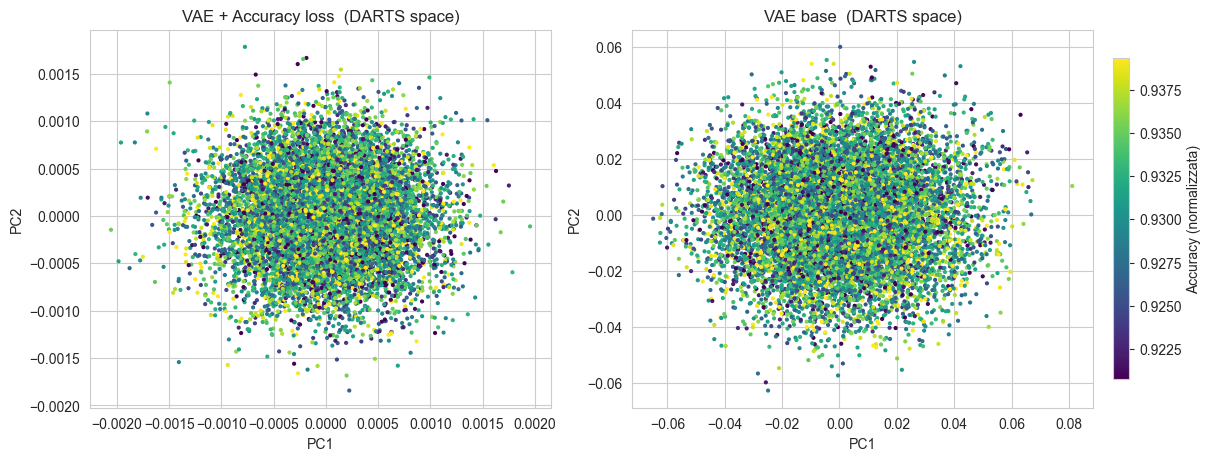

In [38]:
import matplotlib.pyplot as plt

y_train_np = y_train.numpy()
vmin, vmax = np.percentile(y_train_np, [5, 95])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# ── VAE + Accuracy loss ──────────────────────────────────────────────────
sc0 = axes[0].scatter(
    z_2d_acc[:, 0], z_2d_acc[:, 1],
    c=y_train_np, cmap='viridis',
    s=4, vmin=vmin, vmax=vmax
)
axes[0].set_title('VAE + Accuracy loss  (DARTS space)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# ── VAE base ─────────────────────────────────────────────────────────────
sc1 = axes[1].scatter(
    z_2d_base[:, 0], z_2d_base[:, 1],
    c=y_train_np, cmap='viridis',
    s=4, vmin=vmin, vmax=vmax
)
axes[1].set_title('VAE base  (DARTS space)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
cbar.set_label('Accuracy (normalizzata)')

plt.show()

## (Opzionale) UMAP — proiezione alternativa a PCA

Con 32 dimensioni latenti, UMAP spesso rivela strutture non-lineari che la PCA non cattura.  
Richiede `pip install umap-learn`.

In [39]:
# !pip install umap-learn

# import umap
# reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=seed)
# z_2d_umap = reducer.fit_transform(z_acc)

# plt.figure(figsize=(6, 5))
# plt.scatter(z_2d_umap[:, 0], z_2d_umap[:, 1],
#             c=y_train_np, cmap='viridis', s=4, vmin=vmin, vmax=vmax)
# plt.colorbar(label='Accuracy')
# plt.title('UMAP — VAE + Accuracy loss (DARTS)')
# plt.show()

# Flow Matching nello spazio latente DARTS

**Per eseguire questa sezione: runna prima le celle del VAE + accuracy loss, non quelle del VAE base.**

Stesso approccio del notebook NATS-Bench:
1. Divido le architetture in due classi (bassa / alta accuracy)
2. Addestro un `FlowNet` che impara a mappare punti latenti da accuratezza bassa verso accuratezza alta
3. Valuto su test set (architetture mai viste durante il training)

In [40]:
# Recupero z dal train set (già calcolato sopra)
# z_acc shape: (train_size, LATENT_DIM)

y_np_train = y_train.numpy()
idx_sorted = np.argsort(y_np_train)

n = len(y_np_train)
k = n // 2

low_mask  = np.zeros(n, dtype=bool)
high_mask = np.zeros(n, dtype=bool)
low_mask[idx_sorted[:k]]  = True
high_mask[idx_sorted[k:2*k]] = True

z_low  = z_acc[low_mask]
z_high = z_acc[high_mask]

print(f'z_low shape:  {z_low.shape}')
print(f'z_high shape: {z_high.shape}')
print(f'Accuracy media low : {y_np_train[low_mask].mean():.4f}')
print(f'Accuracy media high: {y_np_train[high_mask].mean():.4f}')

z_low shape:  (6000, 32)
z_high shape: (6000, 32)
Accuracy media low : 0.9264
Accuracy media high: 0.9355


In [41]:
class FlowNet(nn.Module):
    """Predice il vettore di flusso v(z) che muove z da bassa ad alta accuracy."""
    def __init__(self, dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, dim)
        )

    def forward(self, x):
        return self.net(x)


def flow_loss(model, x, y):
    """Regressione sul vettore differenza z_high - z_low."""
    target = y - x
    pred   = model(x)
    return ((pred - target) ** 2).mean()

In [42]:
flow_net = FlowNet(dim=LATENT_DIM).to(DEVICE)
opt_flow = torch.optim.Adam(flow_net.parameters(), lr=1e-3)

z_low_t  = torch.tensor(z_low,  dtype=torch.float32).to(DEVICE)
z_high_t = torch.tensor(z_high, dtype=torch.float32).to(DEVICE)

for epoch in range(300):
    loss = flow_loss(flow_net, z_low_t, z_high_t)
    opt_flow.zero_grad()
    loss.backward()
    opt_flow.step()
    if epoch % 50 == 0:
        print(f'Epoch {epoch:>3} | Flow loss: {loss.item():.6f}')

Epoch   0 | Flow loss: 0.001879
Epoch  50 | Flow loss: 0.000001
Epoch 100 | Flow loss: 0.000000
Epoch 150 | Flow loss: 0.000000
Epoch 200 | Flow loss: 0.000000
Epoch 250 | Flow loss: 0.000000


In [43]:
# Costruisco il PCA globale su tutto il training set
pca_global = PCA(n_components=2)
pca_global.fit(z_acc)

vae_train_2d = pca_global.transform(z_acc)

# Proiezione flow field sul training set (low subset)
flow_net.eval()
with torch.no_grad():
    v_train = flow_net(z_low_t)
v_train_np = v_train.cpu().numpy()

z_low_2d   = pca_global.transform(z_low)
z_next_2d  = pca_global.transform(z_low + v_train_np)
v_2d_train = z_next_2d - z_low_2d

# Test set
X_test_all = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
y_test_np  = np.array([test_dataset[i][1].item() for i in range(len(test_dataset))])

with torch.no_grad():
    mu_test, _ = model_acc.encode(X_test_all.to(DEVICE))
z_test_np = mu_test.cpu().numpy()

# Sottoinsieme low del test
test_sorted = np.argsort(y_test_np)
k_test      = len(y_test_np) // 2
low_idx_test = test_sorted[:k_test]
z_low_test   = z_test_np[low_idx_test]

z_low_test_t = torch.tensor(z_low_test, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    v_test   = flow_net(z_low_test_t)
v_test_np = v_test.cpu().numpy()

z_low_test_2d  = pca_global.transform(z_low_test)
z_next_test_2d = pca_global.transform(z_low_test + v_test_np)
v_2d_test      = z_next_test_2d - z_low_test_2d
vae_test_2d    = pca_global.transform(z_test_np)

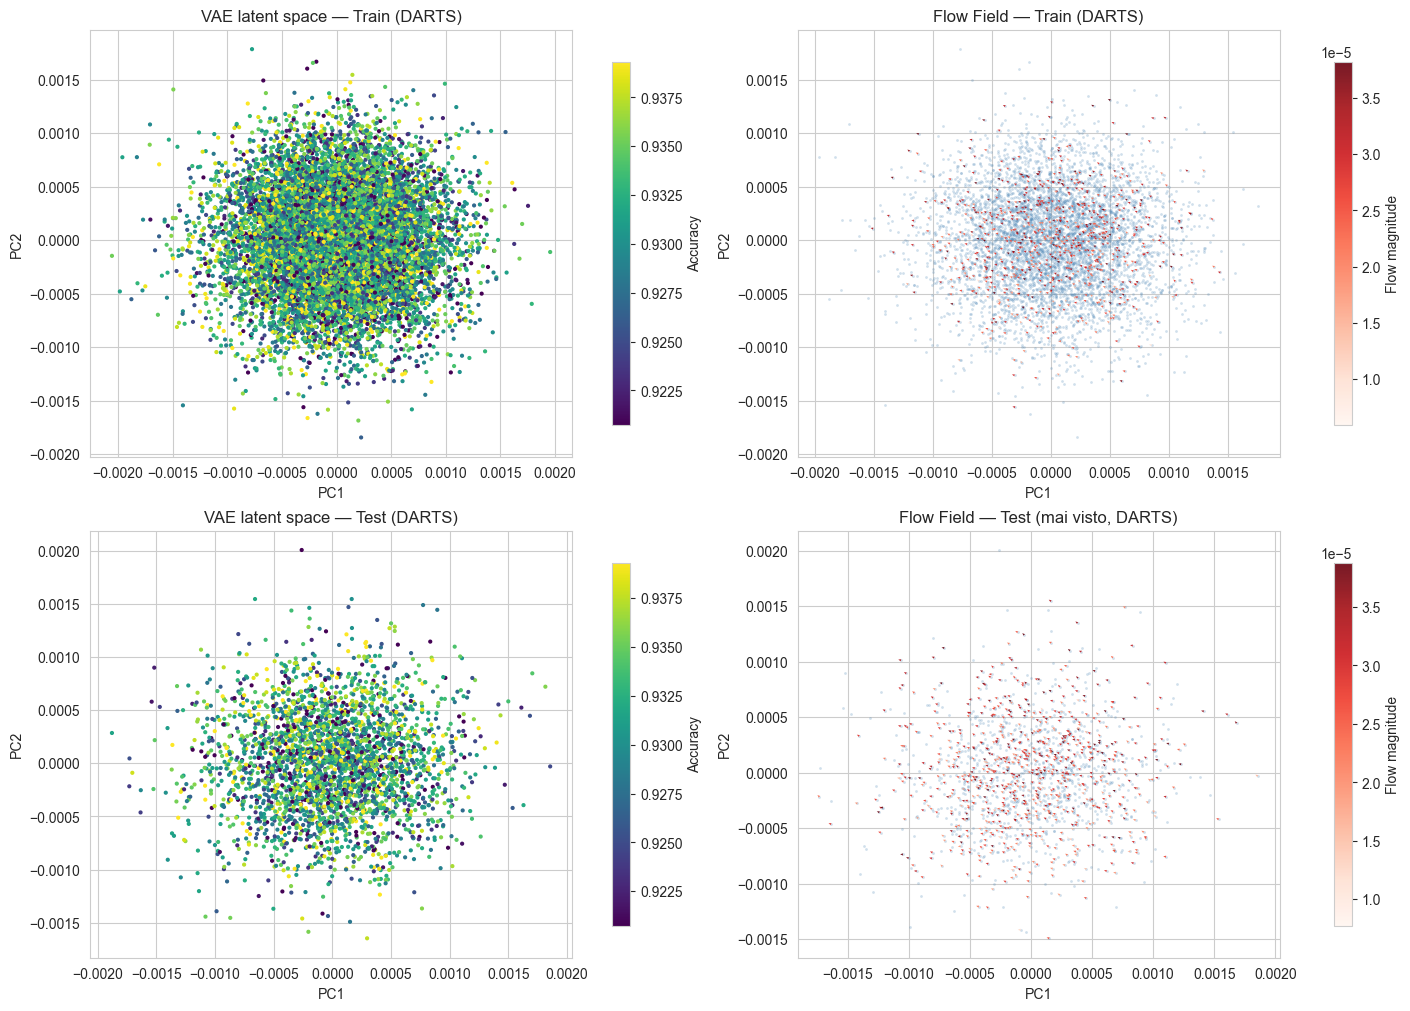

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

# ── helper per quiver normalizzato ─────────────────────────────────────
def plot_quiver(ax, z_2d, v_2d, n_arrows=800):
    v_mag  = np.linalg.norm(v_2d, axis=1)
    v_norm = v_2d / (v_mag[:, None] + 1e-8)
    alen   = np.percentile(v_mag, 30)
    idx    = np.random.choice(len(z_2d), size=min(n_arrows, len(z_2d)), replace=False)
    ax.scatter(z_2d[:, 0], z_2d[:, 1],
               color='steelblue', s=4, alpha=0.25, linewidths=0, zorder=2)
    q = ax.quiver(
        z_2d[idx, 0], z_2d[idx, 1],
        v_norm[idx, 0] * alen, v_norm[idx, 1] * alen,
        v_mag[idx], cmap='Reds',
        norm=plt.Normalize(vmin=v_mag.min(), vmax=np.percentile(v_mag, 95)),
        angles='xy', scale_units='xy', scale=1,
        width=0.002, headwidth=4, headlength=5, alpha=0.9, zorder=3
    )
    return q


# (0,0) — Latent space train
sc0 = axes[0, 0].scatter(
    vae_train_2d[:, 0], vae_train_2d[:, 1],
    c=y_train.numpy(), cmap='viridis',
    s=4, vmin=vmin, vmax=vmax
)
axes[0, 0].set_title('VAE latent space — Train (DARTS)')
axes[0, 0].set_xlabel('PC1'); axes[0, 0].set_ylabel('PC2')
fig.colorbar(sc0, ax=axes[0, 0], shrink=0.85).set_label('Accuracy')

# (0,1) — Flow field train
q0 = plot_quiver(axes[0, 1], z_low_2d, v_2d_train)
axes[0, 1].set_title('Flow Field — Train (DARTS)')
axes[0, 1].set_xlabel('PC1'); axes[0, 1].set_ylabel('PC2')
fig.colorbar(q0, ax=axes[0, 1], shrink=0.85).set_label('Flow magnitude')

# (1,0) — Latent space test
sc1 = axes[1, 0].scatter(
    vae_test_2d[:, 0], vae_test_2d[:, 1],
    c=y_test_np, cmap='viridis',
    s=4, vmin=vmin, vmax=vmax
)
axes[1, 0].set_title('VAE latent space — Test (DARTS)')
axes[1, 0].set_xlabel('PC1'); axes[1, 0].set_ylabel('PC2')
fig.colorbar(sc1, ax=axes[1, 0], shrink=0.85).set_label('Accuracy')

# (1,1) — Flow field test
q1 = plot_quiver(axes[1, 1], z_low_test_2d, v_2d_test)
axes[1, 1].set_title('Flow Field — Test (mai visto, DARTS)')
axes[1, 1].set_xlabel('PC1'); axes[1, 1].set_ylabel('PC2')
fig.colorbar(q1, ax=axes[1, 1], shrink=0.85).set_label('Flow magnitude')

plt.show()

## (Extra) Decodifica — z_moved → architettura

Possiamo applicare il flusso su un punto latente e poi decodificare.  
Il decoder produce un vettore continuo: dobbiamo discretizzarlo per ottenere un Genotype valido.

In [45]:
def tensor_to_genotype(flat_tensor):
    """
    Converte un vettore piatto (576,) in un Genotype DARTS.
    Strategia greedy: per ogni nodo e ogni arco, prende l'op con valore massimo.
    """
    A = flat_tensor.reshape(2, N_OPS, TOTAL_NODES, TOTAL_NODES)

    def decode_cell(cell_A):
        # cell_A: (8, 6, 6)
        edges = []
        for dst_offset in range(N_NODES):
            dst = N_INPUTS + dst_offset
            n_avail = N_INPUTS + dst_offset  # predecessori disponibili
            # Matrice (op, src) per questo nodo
            scores = cell_A[:, :n_avail, dst]   # (8, n_avail)
            # Prendi i 2 src con valore massimo (sommando sulle op)
            src_scores = scores.max(axis=0)      # (n_avail,)
            top2_srcs  = np.argsort(src_scores)[-2:]  # 2 sorgenti migliori
            for src in sorted(top2_srcs):
                best_op = PRIMITIVES[scores[:, src].argmax()]
                edges.append((best_op, int(src)))
        return edges

    normal = decode_cell(A[0].numpy() if torch.is_tensor(A) else A[0])
    reduce = decode_cell(A[1].numpy() if torch.is_tensor(A) else A[1])

    return Genotype(
        normal=normal,
        normal_concat=list(range(N_INPUTS, TOTAL_NODES)),
        reduce=reduce,
        reduce_concat=list(range(N_INPUTS, TOTAL_NODES)),
    )


# Test su un'architettura low-accuracy → applico flusso → decodifico
z_example   = z_low_t[[0]]

with torch.no_grad():
    v_example    = flow_net(z_example)
    z_moved      = z_example + v_example
    recon_before = model_acc.decode(z_example).cpu().numpy()[0]
    recon_after  = model_acc.decode(z_moved).cpu().numpy()[0]

geno_before = tensor_to_genotype(recon_before)
geno_after  = tensor_to_genotype(recon_after)

acc_before = performance_model.predict(config=geno_before, representation='genotype', with_noise=False)
acc_after  = performance_model.predict(config=geno_after,  representation='genotype', with_noise=False)

print('Architettura PRIMA del flusso:')
print(geno_before)
print(f'  → Accuracy predetta: {acc_before:.2f}%')
print()
print('Architettura DOPO il flusso:')
print(geno_after)
print(f'  → Accuracy predetta: {acc_after:.2f}%')
print(f'\n  Δ accuracy: {acc_after - acc_before:+.2f}%')

Architettura PRIMA del flusso:
Genotype(normal=[('dil_conv_5x5', 0), ('dil_conv_5x5', 1), ('dil_conv_5x5', 1), ('max_pool_3x3', 2), ('dil_conv_3x3', 0), ('max_pool_3x3', 1), ('skip_connect', 1), ('sep_conv_5x5', 2)], normal_concat=[2, 3, 4, 5], reduce=[('sep_conv_5x5', 0), ('skip_connect', 1), ('skip_connect', 1), ('sep_conv_3x3', 2), ('dil_conv_5x5', 1), ('sep_conv_5x5', 3), ('dil_conv_5x5', 1), ('sep_conv_3x3', 4)], reduce_concat=[2, 3, 4, 5])
  → Accuracy predetta: 92.85%

Architettura DOPO il flusso:
Genotype(normal=[('dil_conv_5x5', 0), ('dil_conv_5x5', 1), ('dil_conv_5x5', 1), ('max_pool_3x3', 2), ('dil_conv_3x3', 0), ('max_pool_3x3', 1), ('skip_connect', 1), ('sep_conv_5x5', 2)], normal_concat=[2, 3, 4, 5], reduce=[('sep_conv_5x5', 0), ('skip_connect', 1), ('skip_connect', 1), ('sep_conv_3x3', 2), ('dil_conv_5x5', 1), ('sep_conv_5x5', 3), ('dil_conv_5x5', 1), ('sep_conv_3x3', 4)], reduce_concat=[2, 3, 4, 5])
  → Accuracy predetta: 92.85%

  Δ accuracy: +0.00%
